An undergraduate project on crop selection prediction using Feedfoward Neural network. 
    

# WEATHER DATA

In [2]:
# Libraries importation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim 
import table_evaluator

from numpy import interp
from scipy.stats.mstats import winsorize 
from ctgan import CTGAN
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
 
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importing the data
weather_df = pd.read_csv(r"C:\Users\DELL\Deployment\final_year_project\Weather.csv")

In [5]:
# To check the first 5 rows
weather_df.head()

,Year,Day,T2m_Range,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Surface_soil_wetness,Root_Zone_Soil_Wetness
0,2010,1,19.35,33.55,14.20,0.0,26.13,2.92,0.35,0.42
1,2010,2,19.88,33.37,13.49,0.0,23.75,3.11,0.35,0.42
2,2010,3,19.79,32.23,12.44,0.0,22.46,3.36,0.35,0.42
3,2010,4,20.40,32.74,12.34,0.0,25.80,1.91,0.35,0.42
4,2010,5,18.47,32.37,13.90,0.0,30.21,1.67,0.35,0.42


In [6]:
# To check the details about the data
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5845 entries, 0 to 5844
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    5845 non-null   int64  
 1   Day                     5845 non-null   int64  
 2   T2m_Range               5845 non-null   float64
 3   T2m_Max                 5845 non-null   float64
 4   T2m_Min                 5845 non-null   float64
 5   Precipitation           5845 non-null   float64
 6   Relative_humidity_2_m   5845 non-null   float64
 7   Wind_speed_2_m          5845 non-null   float64
 8   Surface_soil_wetness    5845 non-null   float64
 9   Root_Zone_Soil_Wetness  5845 non-null   float64
dtypes: float64(8), int64(2)
memory usage: 456.8 KB


In [7]:
# Looking for missing values
missing_values = weather_df.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [8]:
# Checking for duplicates
weather_df.duplicated().sum()

0

Yes, daily precipitation can be 0.0 mm (0.0 inches) in Kaduna North, particularly during the dry season which lasts for about 6.4 months from October to April.

In summary, 0.0 mm daily precipitation is a standard occurrence in Kaduna North for a large portion of the year.

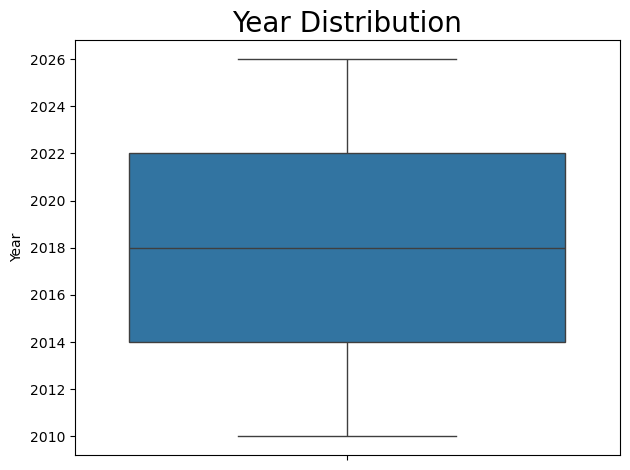

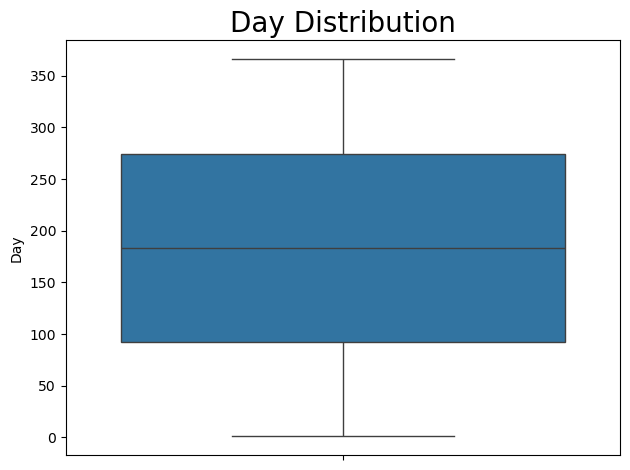

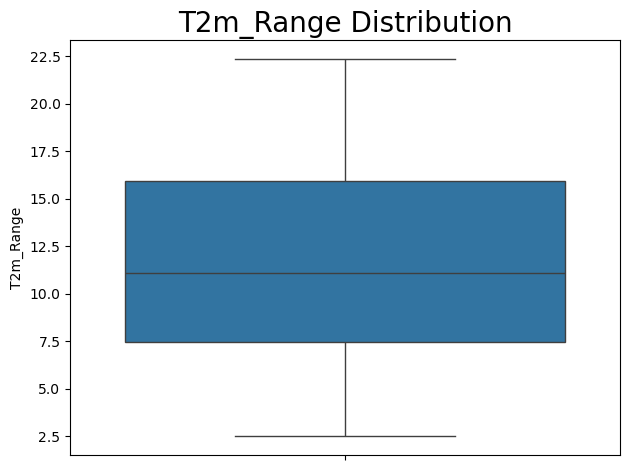

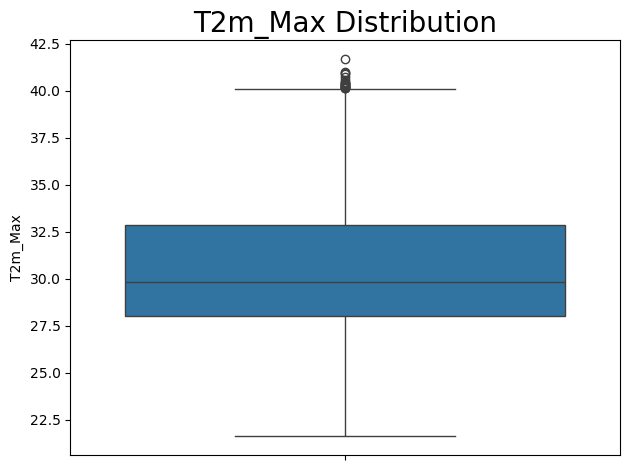

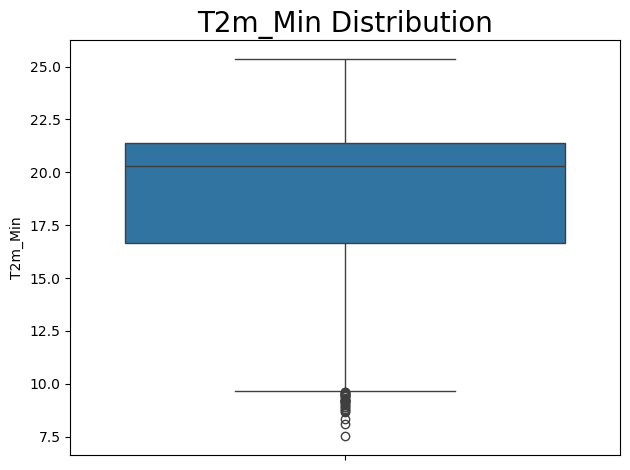

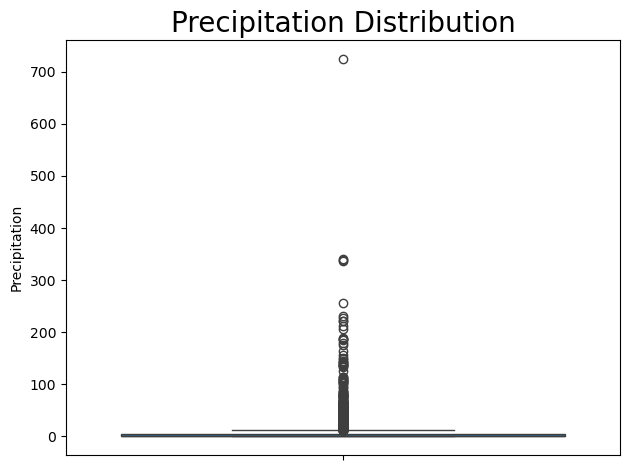

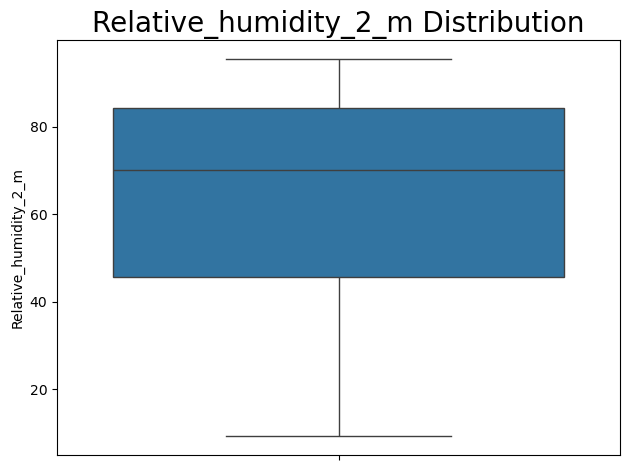

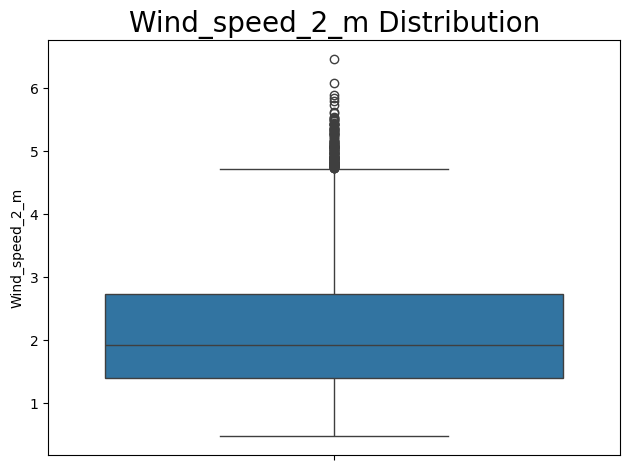

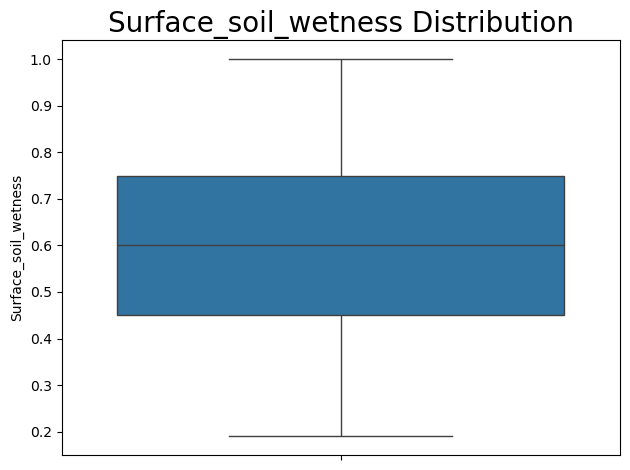

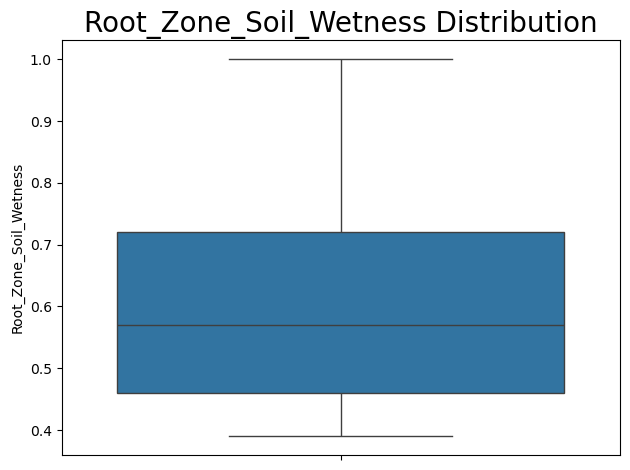

In [9]:
# Looking for outliers
for col in weather_df.columns:
    sns.boxplot(weather_df[col], orient = 'x')
    plt.title(f'{col} Distribution', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.show()

In [10]:
for col in ['T2m_Max', 'T2m_Min', 'Precipitation', 'Wind_speed_2_m']:
    weather_df[col] = winsorize(weather_df[col], limits = [0.05, 0.05])

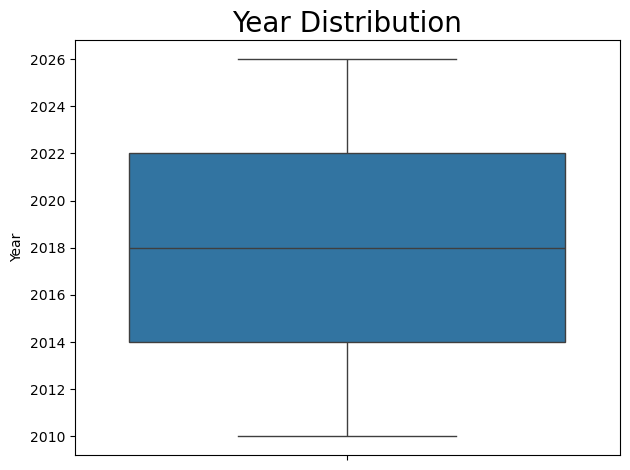

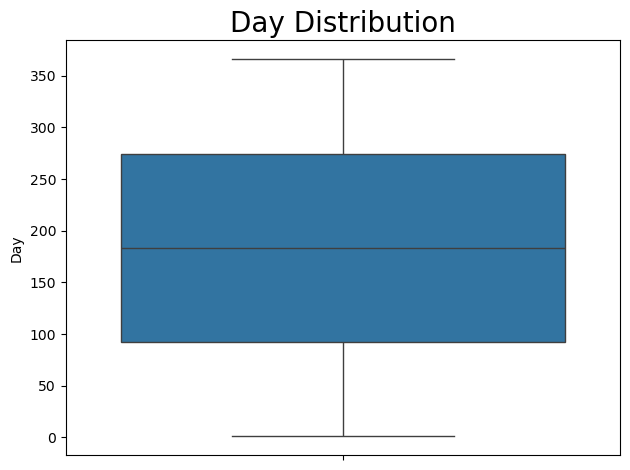

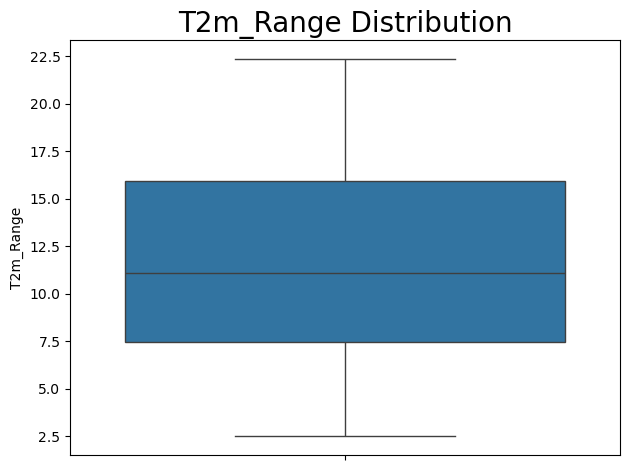

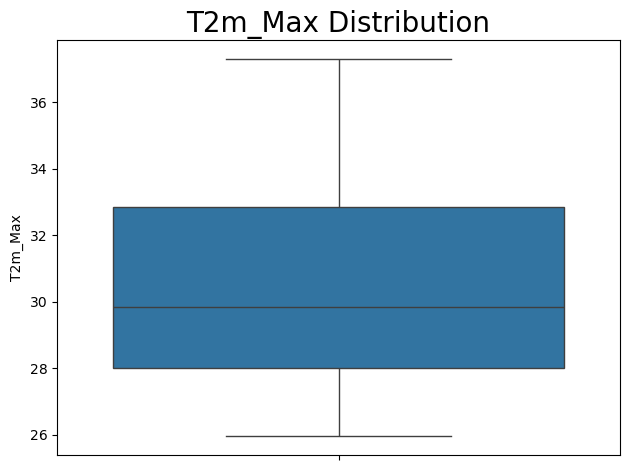

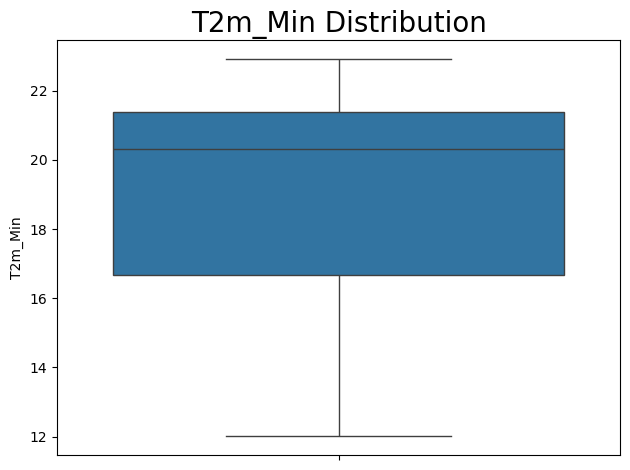

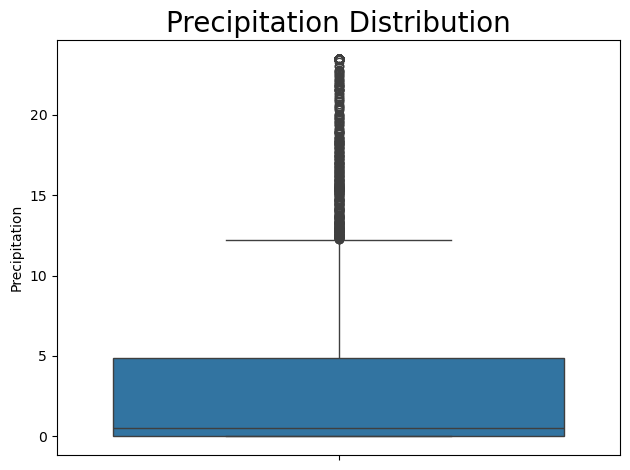

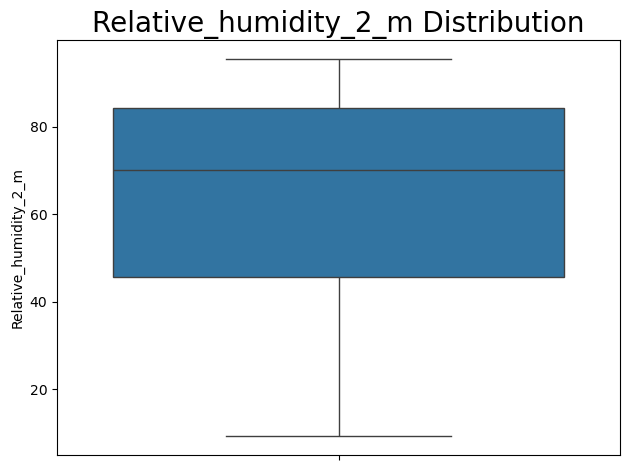

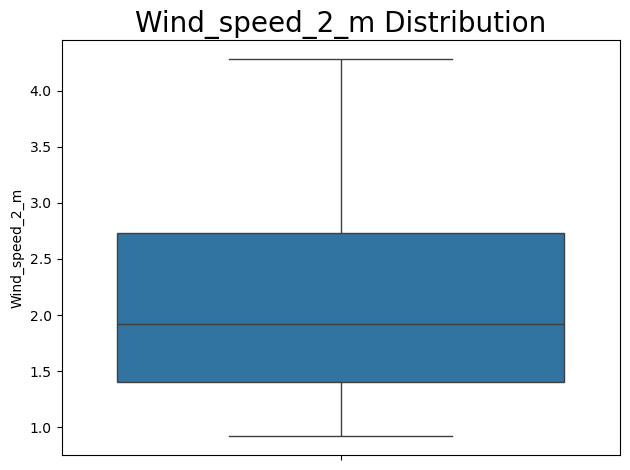

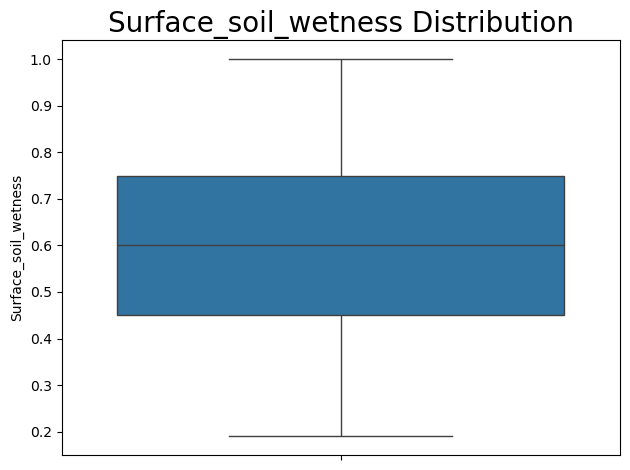

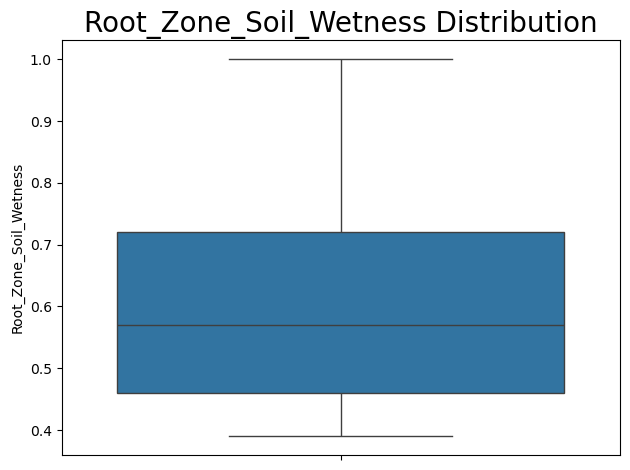

In [11]:
for col in weather_df.columns:
    sns.boxplot(weather_df[col], orient = 'x')
    plt.title(f'{col} Distribution', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.show()

In [12]:
weather_df['Precipitation'] = winsorize(weather_df['Precipitation'], limits = [0.15, 0.15])

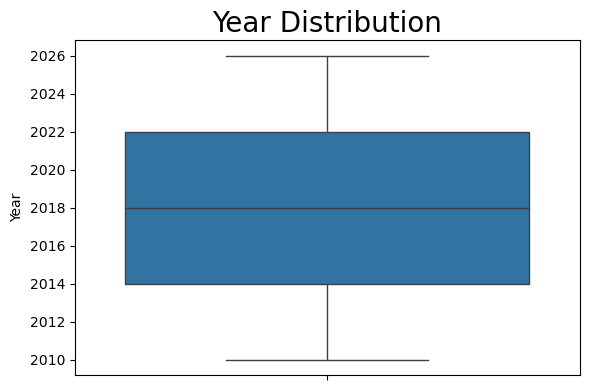

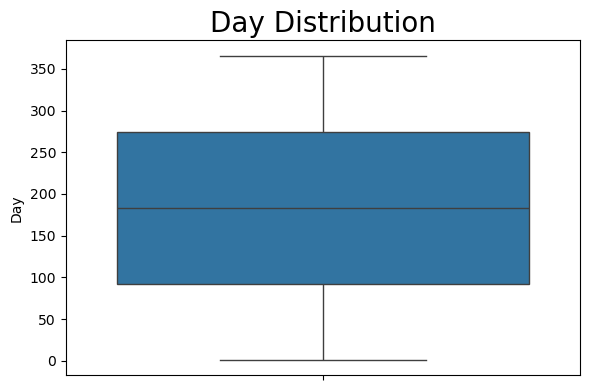

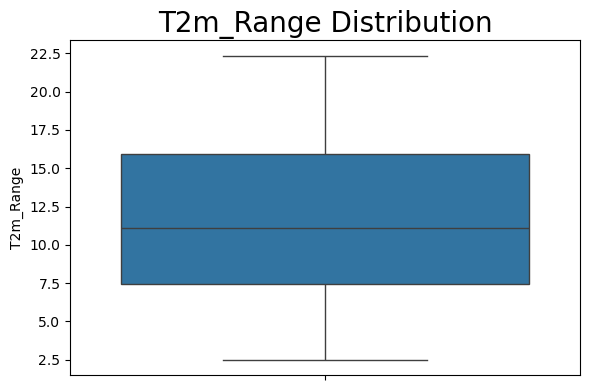

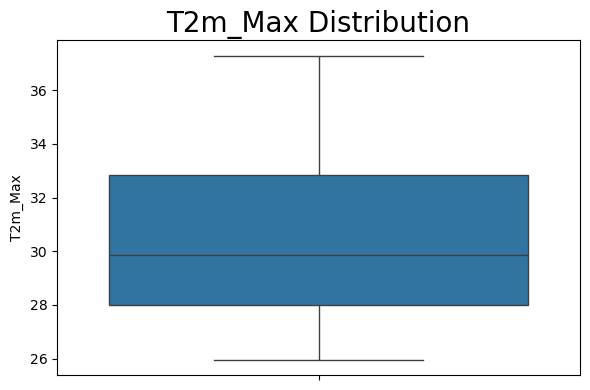

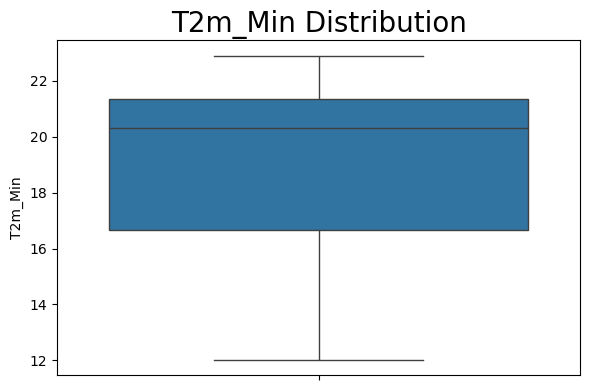

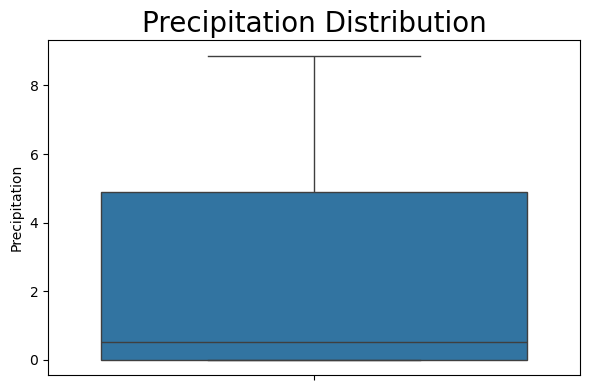

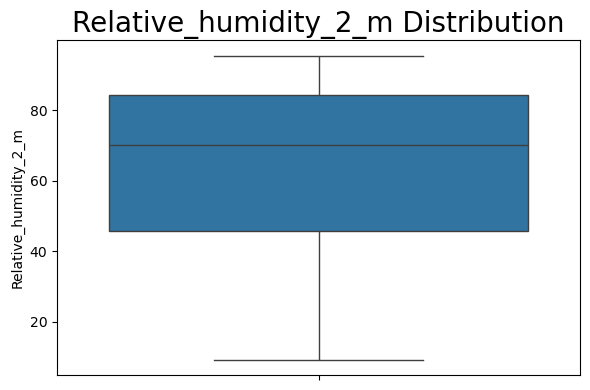

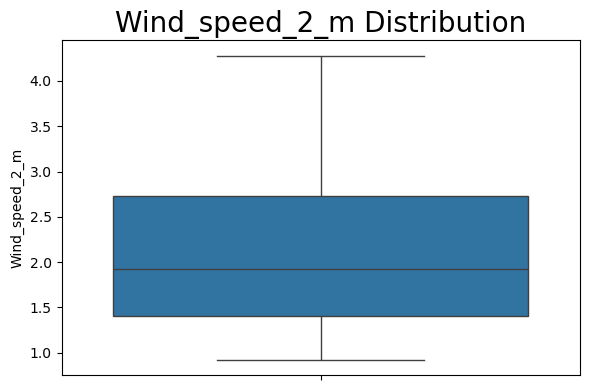

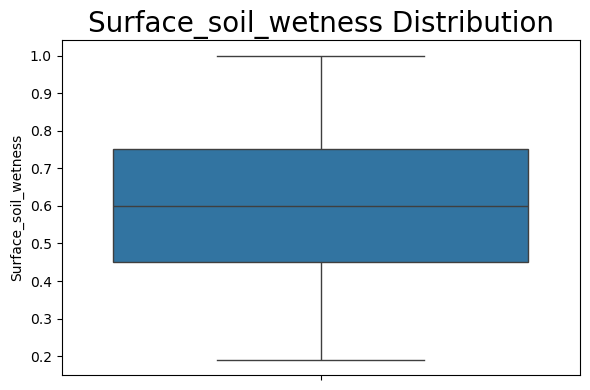

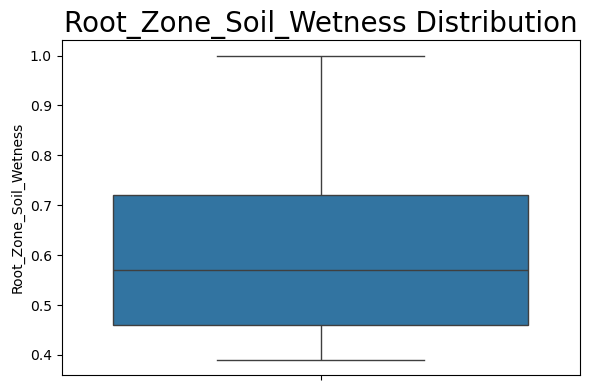

In [13]:
for col in weather_df.columns:
    plt.figure(figsize = (6, 4))
    sns.boxplot(weather_df[col], orient = 'x')
    plt.title(f'{col} Distribution', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.show()

In [14]:
weather_df.describe()

,Year,Day,T2m_Range,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Surface_soil_wetness,Root_Zone_Soil_Wetness
count,5845.000000,5845.000000,5845.000000,5845.000000,5845.000000,5845.000000,5845.000000,5845.000000,5845.000000,5845.000000
mean,2017.501796,183.094098,11.629824,30.586821,19.005141,2.638881,64.147406,2.154364,0.597437,0.602513
std,4.611038,105.465550,4.618072,3.289785,3.262933,3.384170,22.488362,0.958824,0.188712,0.163693
min,2010.000000,1.000000,2.490000,25.950000,12.010000,0.000000,9.190000,0.920000,0.190000,0.390000
25%,2014.000000,92.000000,7.470000,28.000000,16.680000,0.000000,45.580000,1.400000,0.450000,0.460000
50%,2018.000000,183.000000,11.090000,29.850000,20.300000,0.510000,70.140000,1.920000,0.600000,0.570000
75%,2022.000000,274.000000,15.950000,32.850000,21.370000,4.900000,84.290000,2.730000,0.750000,0.720000
max,2026.000000,366.000000,22.350000,37.290000,22.910000,8.870000,95.430000,4.280000,1.000000,1.000000


In [15]:
df_yearly = weather_df.groupby("Year").agg({
    "T2m_Max": "mean", "T2m_Min": "mean",
    "T2m_Range": "mean","Precipitation": "sum",
    "Relative_humidity_2_m": "mean", "Wind_speed_2_m": "mean",
    "Surface_soil_wetness": "mean","Root_Zone_Soil_Wetness": "mean"}).reset_index()

df_yearly = df_yearly.drop(columns = ["Year"])

In [16]:
df_yearly

,T2m_Max,T2m_Min,T2m_Range,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Surface_soil_wetness,Root_Zone_Soil_Wetness
0,31.085534,19.600603,11.589699,1014.43,62.411205,2.135041,0.514932,0.534603
1,31.282904,18.792740,12.611534,897.02,59.460603,2.172685,0.508329,0.509205
2,30.363388,18.925301,11.469235,1259.25,63.799098,2.139180,0.594536,0.601749
3,31.604110,19.352795,12.266411,684.01,62.167260,2.011836,0.481452,0.483726
4,31.558932,19.624356,11.942247,958.62,59.349397,2.117370,0.487123,0.507507
5,31.135068,19.172575,12.180274,900.97,58.344685,2.339781,0.545068,0.571562
6,30.292240,18.972432,11.348060,1034.39,65.996093,2.067049,0.623907,0.612158
7,30.567014,18.884301,11.677014,953.76,63.010082,2.134411,0.621014,0.621562
8,30.523425,18.987945,11.556247,945.19,64.491233,2.069370,0.587589,0.582904
9,30.790329,19.322493,11.489890,924.55,63.853096,2.090603,0.564274,0.561699


Why did i aggregate this way?

Because:

Rainfall accumulates so it must sum

Temperature describes climate  mean is meaningful

Soil wetness reflects seasonal moisture  mean works

# FEATURE ENGINEERING

In [18]:
# Heat Stress, this is because hign temperature damage crops.
df_yearly["Heat_Stress"] = (df_yearly["T2m_Max"] - df_yearly["T2m_Min"])

In [19]:
# Moisture Balance
# This tells if rainfall tanslate into usable soil water
df_yearly["Moisture Balance"] = df_yearly["Precipitation"] / (df_yearly["Root_Zone_Soil_Wetness"] + 0.00001) 

In [20]:
# Drought Proxy = Hot + low rainfall = bad for many crops.
df_yearly["Dryness_index"] = (df_yearly["T2m_Max"] / df_yearly["Precipitation"])


In [21]:
df_yearly

,T2m_Max,T2m_Min,T2m_Range,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Surface_soil_wetness,Root_Zone_Soil_Wetness,Heat_Stress,Moisture Balance,Dryness_index
0,31.085534,19.600603,11.589699,1014.43,62.411205,2.135041,0.514932,0.534603,11.484932,1897.504352,0.030643
1,31.282904,18.792740,12.611534,897.02,59.460603,2.172685,0.508329,0.509205,12.490164,1761.572529,0.034874
2,30.363388,18.925301,11.469235,1259.25,63.799098,2.139180,0.594536,0.601749,11.438087,2092.616423,0.024112
3,31.604110,19.352795,12.266411,684.01,62.167260,2.011836,0.481452,0.483726,12.251315,1414.015003,0.046204
4,31.558932,19.624356,11.942247,958.62,59.349397,2.117370,0.487123,0.507507,11.934575,1888.843693,0.032921
5,31.135068,19.172575,12.180274,900.97,58.344685,2.339781,0.545068,0.571562,11.962493,1576.302830,0.034557
6,30.292240,18.972432,11.348060,1034.39,65.996093,2.067049,0.623907,0.612158,11.319809,1689.714598,0.029285
7,30.567014,18.884301,11.677014,953.76,63.010082,2.134411,0.621014,0.621562,11.682712,1534.432932,0.032049
8,30.523425,18.987945,11.556247,945.19,64.491233,2.069370,0.587589,0.582904,11.535479,1621.491030,0.032293
9,30.790329,19.322493,11.489890,924.55,63.853096,2.090603,0.564274,0.561699,11.467836,1645.960112,0.033303


I removed the year column because i don't want the model to memorize year, i want it to generalize better and climate crop relationship.

# YIELD DATA

In [ ]:
yield_df = pd.read_csv(r"C:\Users\DELL\Deployment\final_year_project\KADA_Agricultural_Production_Normalized.csv")

In [ ]:
yield_df.head()

In [ ]:
yield_df.info()

# pip install ctgan
Installing CTGAN Which stands for conditional tabular GAN, is a python library use for data augmentation. 
Data augmentation increases dataset size and diversity to create more synthetic data from real world data. 
It help machine learning models learn meaningful patterns, generalize better and avoid overfitting. 
It is usualy used when the real dataset is too small.

In [ ]:
# Installing table evaluator to evaluate the quality of the synthetic data. 
# To compare a sy%pip install table_evaluator
# %pip install table_evaluator